#NLP Preprocessing and Text Classification
### Name: Rupali Sutar
#### PRN: 202402060030
####batch: T4
####github link:
**Objective:** Implement NLP preprocessing techniques and build a text classification model using machine learning.

| Item | Detail |
|------|--------|
| **Dataset** | Custom 4-class newsgroup CSV (120 samples) + 20 Newsgroups (sklearn) |
| **NLP Tools** | NLTK – tokenization, stopwords, stemming, lemmatization |
| **Vectorizers** | CountVectorizer (BoW) · TF-IDF |
| **Models** | Naïve Bayes · Logistic Regression · Linear SVC |
| **Metrics** | Accuracy · Precision · Recall · F1 · Confusion Matrix · CV |

In [10]:
!pip install -q nltk scikit-learn matplotlib seaborn pandas numpy

In [11]:
# ── Imports ──────────────────────────────────────────────────────────────────
import re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# NLTK
import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus   import stopwords
from nltk.stem     import PorterStemmer, WordNetLemmatizer

# Scikit-learn
from sklearn.datasets                import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection         import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes             import MultinomialNB
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.metrics                 import (accuracy_score, classification_report,
                                             confusion_matrix, ConfusionMatrixDisplay)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [12]:
# ── Upload the CSV provided with this notebook ────────────────────────────────
from google.colab import files

print('Please upload  newsgroups_dataset.csv  when prompted below.')
uploaded = files.upload()   # click "Choose Files" and select the CSV

import io
csv_filename = list(uploaded.keys())[0]
df_custom = pd.read_csv(io.BytesIO(uploaded[csv_filename]))

print(f'\n✅ Loaded custom dataset: {df_custom.shape[0]} rows, {df_custom["label"].nunique()} classes')
print(df_custom['label'].value_counts())
df_custom.head()

Please upload  newsgroups_dataset.csv  when prompted below.


Saving newsgroups_dataset.csv to newsgroups_dataset (1).csv

✅ Loaded custom dataset: 120 rows, 4 classes
label
sci.space             30
rec.sport.hockey      30
talk.politics.guns    30
sci.med               30
Name: count, dtype: int64


,text,label
0,NASA is planning to return humans to the Moon ...,sci.space
1,The power forward played his 1000th career NHL...,rec.sport.hockey
2,A new poll shows majority of Americans support...,talk.politics.guns
3,Advocates call for smarter gun technology to p...,talk.politics.guns
4,The Supreme Court will hear arguments on the c...,talk.politics.guns


In [13]:
# ── 20 Newsgroups — main dataset for model training ───────────────────────────
CATEGORIES = [
    'sci.med',
    'sci.space',
    'rec.sport.hockey',
    'talk.politics.guns',
]

raw_train = fetch_20newsgroups(
    subset='train', categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),  # strip metadata → realistic task
    random_state=42,
)
raw_test = fetch_20newsgroups(
    subset='test', categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),
    random_state=42,
)

CLASS_NAMES = raw_train.target_names
print(f'Training samples : {len(raw_train.data)}')
print(f'Test samples     : {len(raw_test.data)}')
print(f'Classes          : {CLASS_NAMES}')

Training samples : 2333
Test samples     : 1553
Classes          : ['rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.guns']


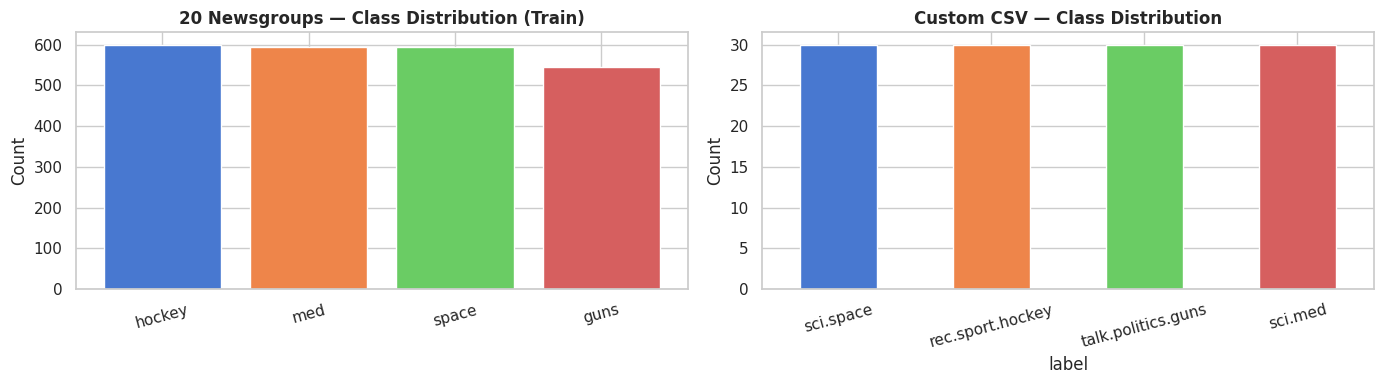


── Sample documents ──

[sci.space]
Wasn't there a "plain" flavor too?  They looked more like some
kind of extruded industrial product than food -- perfectly
smooth cylinders with perfectly smooth ends.  Kinda scary.


An other post described it as like a "microwaved Tootsie Roll" --

[rec.sport.hockey]
Well, I'm a Wings fan and I think the FIRST thing that you should do is to
get the opponent's line combinations correct before you try to match up anyone
with them.  There is no Yzerman-Fedorov-Probert line, except for maybe on a
powerplay.  The


In [14]:
# ── EDA: class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 20 Newsgroups
train_counts = pd.Series(raw_train.target).value_counts().sort_index()
axes[0].bar([CLASS_NAMES[i].split('.')[-1] for i in train_counts.index],
            train_counts.values, color=sns.color_palette('muted', 4))
axes[0].set_title('20 Newsgroups — Class Distribution (Train)', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=15)

# Custom CSV
df_custom['label'].value_counts().plot(kind='bar', ax=axes[1],
    color=sns.color_palette('muted', 4), edgecolor='white')
axes[1].set_title('Custom CSV — Class Distribution', fontweight='bold')
axes[1].set_ylabel('Count'); axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

print('\n── Sample documents ──')
for i in range(2):
    print(f'\n[{CLASS_NAMES[raw_train.target[i]]}]\n{raw_train.data[i][:250].strip()}')

# Step 2 — NLP Preprocessing

In [15]:
# ── Initialise NLP tools ──────────────────────────────────────────────────────
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

print(f'Stop-word vocabulary size: {len(STOP_WORDS)}')
print('Sample stop words:', sorted(list(STOP_WORDS))[:15])

Stop-word vocabulary size: 198
Sample stop words: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [16]:
def preprocess(text: str, *, use_stemming: bool = False,
               use_lemmatization: bool = True) -> str:
    """
    Full NLP preprocessing pipeline.

    Steps
    -----
    1. Lowercase
    2. Remove URLs  (http/www)
    3. Remove e-mail addresses
    4. Remove digits
    5. Remove non-alphabetic characters
    6. Tokenize (NLTK word_tokenize)
    7. Remove stopwords & tokens < 3 chars
    8. Stem (PorterStemmer) OR Lemmatize (WordNetLemmatizer)
    9. Re-join tokens

    Parameters
    ----------
    text              : Raw input text.
    use_stemming      : Apply Porter stemming.
    use_lemmatization : Apply WordNet lemmatization (default=True).

    Returns
    -------
    str : Cleaned text ready for vectorization.
    """
    text = text.lower()                                  # 1. Lowercase
    text = re.sub(r'http\S+|www\S+', ' ', text)        # 2. URLs
    text = re.sub(r'\S+@\S+',        ' ', text)        # 3. Emails
    text = re.sub(r'\d+',             ' ', text)        # 4. Digits
    text = re.sub(r'[^a-z\s]',        ' ', text)        # 5. Punctuation
    tokens = word_tokenize(text)                         # 6. Tokenize
    tokens = [t for t in tokens                          # 7. Stopwords
              if t not in STOP_WORDS and len(t) > 2]
    if use_stemming:                                     # 8a. Stem
        tokens = [stemmer.stem(t) for t in tokens]
    elif use_lemmatization:                              # 8b. Lemmatize
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)                              # 9. Rejoin

print('✅ preprocess() defined.')

✅ preprocess() defined.


In [17]:
# ── Step-by-step demo on a real document ──────────────────────────────────────
demo = raw_train.data[0][:400]

steps = {
    '① Original'          : demo,
    '② Lowercase'         : demo.lower(),
    '③ Noise removed'     : re.sub(r'[^a-z\s]', ' ',
                                re.sub(r'\d+|http\S+|\S+@\S+', ' ', demo.lower())),
    '④ Tokenized'         : ' '.join(word_tokenize(demo.lower())),
    '⑤ Stopwords removed' : ' '.join(t for t in word_tokenize(demo.lower())
                                     if t not in STOP_WORDS and len(t) > 2),
    '⑥ Lemmatized ✓'      : preprocess(demo, use_lemmatization=True),
    '⑦ Stemmed (alt)'     : preprocess(demo, use_stemming=True),
}
for step, result in steps.items():
    print(f'\n{step}')
    print('─' * 60)
    print(result[:200])


① Original
────────────────────────────────────────────────────────────

Wasn't there a "plain" flavor too?  They looked more like some
kind of extruded industrial product than food -- perfectly
smooth cylinders with perfectly smooth ends.  Kinda scary.


An other post de

② Lowercase
────────────────────────────────────────────────────────────

wasn't there a "plain" flavor too?  they looked more like some
kind of extruded industrial product than food -- perfectly
smooth cylinders with perfectly smooth ends.  kinda scary.


an other post de

③ Noise removed
────────────────────────────────────────────────────────────

wasn t there a  plain  flavor too   they looked more like some
kind of extruded industrial product than food    perfectly
smooth cylinders with perfectly smooth ends   kinda scary 


an other post de

④ Tokenized
────────────────────────────────────────────────────────────
was n't there a `` plain '' flavor too ? they looked more like some kind of extruded industrial pr

In [18]:
# ── Apply to full corpus ──────────────────────────────────────────────────────
print('Preprocessing training corpus …')
X_train_clean = [preprocess(t) for t in raw_train.data]

print('Preprocessing test corpus …')
X_test_clean  = [preprocess(t) for t in raw_test.data]

y_train = raw_train.target
y_test  = raw_test.target

# Also apply to custom CSV
df_custom['clean_text'] = df_custom['text'].apply(preprocess)

print('\n✅ Done!')
print(f'Sample cleaned doc:\n{X_train_clean[0][:300]}')

Preprocessing training corpus …
Preprocessing test corpus …

✅ Done!
Sample cleaned doc:
plain flavor looked like kind extruded industrial product food perfectly smooth cylinder perfectly smooth end kinda scary post described like microwaved tootsie roll capture texture pretty well taste like candy sweet make sense recall liking texture taste guess well developed texture bud obligatory 


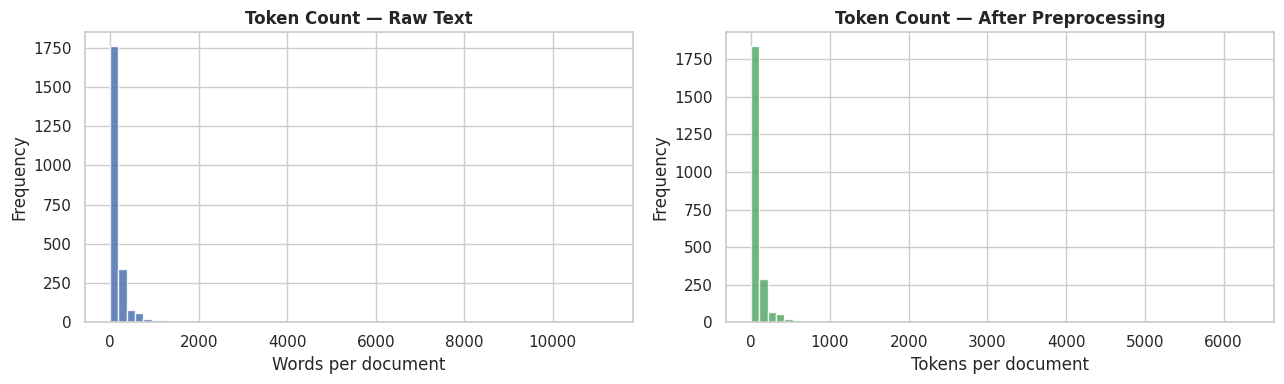

Avg raw tokens   : 204
Avg clean tokens : 105
Vocab reduction  : 48.8%


In [19]:
# ── Token-length distribution ─────────────────────────────────────────────────
raw_len   = [len(t.split()) for t in raw_train.data]
clean_len = [len(t.split()) for t in X_train_clean]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(raw_len,   bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Token Count — Raw Text',               fontweight='bold')
axes[0].set_xlabel('Words per document'); axes[0].set_ylabel('Frequency')

axes[1].hist(clean_len, bins=60, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].set_title('Token Count — After Preprocessing', fontweight='bold')
axes[1].set_xlabel('Tokens per document'); axes[1].set_ylabel('Frequency')

plt.tight_layout(); plt.show()

print(f'Avg raw tokens   : {np.mean(raw_len):.0f}')
print(f'Avg clean tokens : {np.mean(clean_len):.0f}')
print(f'Vocab reduction  : {(1 - np.mean(clean_len)/np.mean(raw_len))*100:.1f}%')

# Step 3 — Text Vectorization


In [20]:
# ── CountVectorizer ───────────────────────────────────────────────────────────
# Counts raw token occurrences; treats all words equally regardless of frequency.
cv_vec = CountVectorizer(
    max_features=20_000,   # vocabulary cap
    ngram_range=(1, 2),    # unigrams + bigrams
)
X_train_cv = cv_vec.fit_transform(X_train_clean)
X_test_cv  = cv_vec.transform(X_test_clean)

print(f'CountVectorizer matrix shape : {X_train_cv.shape}')
print(f'Matrix type (sparse)         : {type(X_train_cv)}')
print(f'Sample features: {cv_vec.get_feature_names_out()[:10].tolist()}')

CountVectorizer matrix shape : (2333, 20000)
Matrix type (sparse)         : <class 'scipy.sparse._csr.csr_matrix'>
Sample features: ['aa', 'aa american', 'aaai', 'aan', 'aaron', 'abandon', 'abandoned', 'abc', 'abc coverage', 'abc news']


In [21]:
##3B. TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # log(1 + tf) — dampens high-frequency terms
    min_df=2,              # ignore tokens appearing in only 1 document
)
X_train_tfidf = tfidf_vec.fit_transform(X_train_clean)
X_test_tfidf  = tfidf_vec.transform(X_test_clean)

print(f'TF-IDF matrix shape : {X_train_tfidf.shape}')
sparsity = (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]))*100
print(f'Sparsity            : {sparsity:.1f}%')

TF-IDF matrix shape : (2333, 20000)
Sparsity            : 99.6%


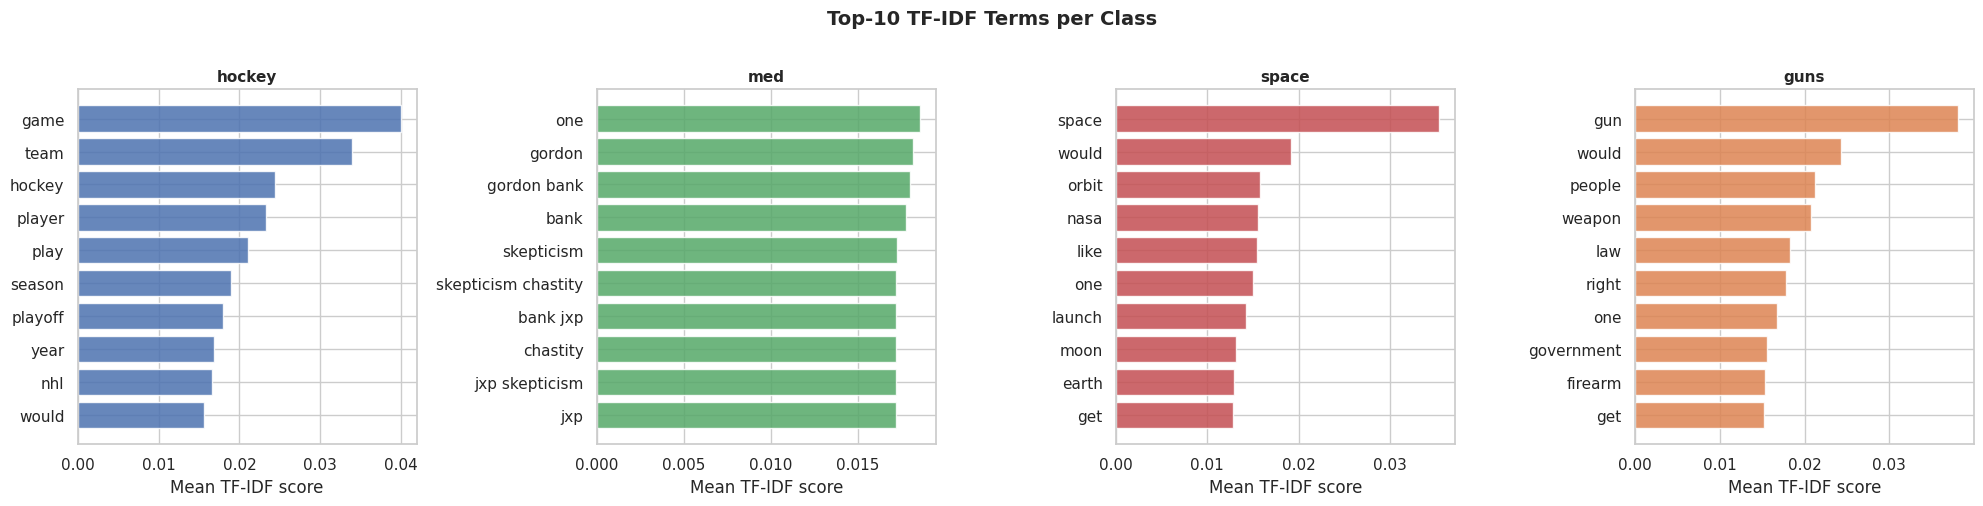

In [22]:
# ── Top-10 TF-IDF terms per class (bar charts) ───────────────────────────────
feature_names = np.array(tfidf_vec.get_feature_names_out())
colors = ['#4C72B0','#55A868','#C44E52','#DD8452']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for cls_idx, (cls_name, ax, col) in enumerate(zip(CLASS_NAMES, axes, colors)):
    mask   = y_train == cls_idx
    mean_v = X_train_tfidf[mask].mean(axis=0).A1
    top10  = np.argsort(mean_v)[-10:][::-1]
    ax.barh(feature_names[top10][::-1], mean_v[top10][::-1], color=col, alpha=0.85)
    ax.set_title(cls_name.split('.')[-1], fontweight='bold', fontsize=11)
    ax.set_xlabel('Mean TF-IDF score')

fig.suptitle('Top-10 TF-IDF Terms per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

Step 4 — Model Building & Training

| Model | Why use it |
|-------|------------|
| **Multinomial Naïve Bayes** | Fast probabilistic baseline; works well with sparse TF-IDF features |
| **Logistic Regression** | Strong discriminative model; outputs calibrated probabilities |
| **Linear SVC** | Maximum-margin; best-in-class for high-dimensional sparse text |

In [23]:
# ── Define classifiers ────────────────────────────────────────────────────────
models = {
    'Naïve Bayes': MultinomialNB(
        alpha=0.1            # Laplace / additive smoothing
    ),
    'Logistic Regression': LogisticRegression(
        C=5,                 # inverse regularization strength
        max_iter=1000,
        solver='saga',       # efficient for large sparse matrices
        random_state=42,
    ),
    'Linear SVC': LinearSVC(
        C=1.0,               # regularization parameter
        max_iter=2000,
        random_state=42,
    ),
}

# ── Train all models ──────────────────────────────────────────────────────────
results = {}

for name, clf in models.items():
    print(f'\nTraining: {name} …')

    clf.fit(X_train_tfidf, y_train)         # Train on TF-IDF features
    y_pred = clf.predict(X_test_tfidf)       # Predict on test set
    acc    = accuracy_score(y_test, y_pred)  # Test accuracy

    # 5-fold stratified cross-validation on training set
    cv_scores = cross_val_score(
        clf, X_train_tfidf, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy',
    )

    results[name] = {
        'model'    : clf,
        'y_pred'   : y_pred,
        'accuracy' : acc,
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std(),
        'cv_scores': cv_scores,
    }

    print(f'  Test Accuracy : {acc:.4f}')
    print(f'  CV Accuracy   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print('\n✅ All models trained!')


Training: Naïve Bayes …
  Test Accuracy : 0.8950
  CV Accuracy   : 0.9181 ± 0.0093

Training: Logistic Regression …
  Test Accuracy : 0.8783
  CV Accuracy   : 0.9104 ± 0.0055

Training: Linear SVC …
  Test Accuracy : 0.8744
  CV Accuracy   : 0.9087 ± 0.0067

✅ All models trained!


# Step 5 — Model Evaluation

In [24]:
# ── Classification reports (precision / recall / F1) ─────────────────────────
short_names = [c.split('.')[-1] for c in CLASS_NAMES]

for name, res in results.items():
    print(f'\n{"═"*60}')
    print(f'  {name}')
    print(f'{"═"*60}')
    print(classification_report(y_test, res['y_pred'], target_names=short_names))


════════════════════════════════════════════════════════════
  Naïve Bayes
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      hockey       0.88      0.94      0.91       399
         med       0.93      0.87      0.90       396
       space       0.90      0.88      0.89       394
        guns       0.88      0.89      0.89       364

    accuracy                           0.90      1553
   macro avg       0.90      0.89      0.89      1553
weighted avg       0.90      0.90      0.89      1553


════════════════════════════════════════════════════════════
  Logistic Regression
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      hockey       0.97      0.92      0.94       399
         med       0.88      0.86      0.87       396
       space       0.80      0.89      0.84       394
        guns       0.88      0.85      0.86       364

    accurac

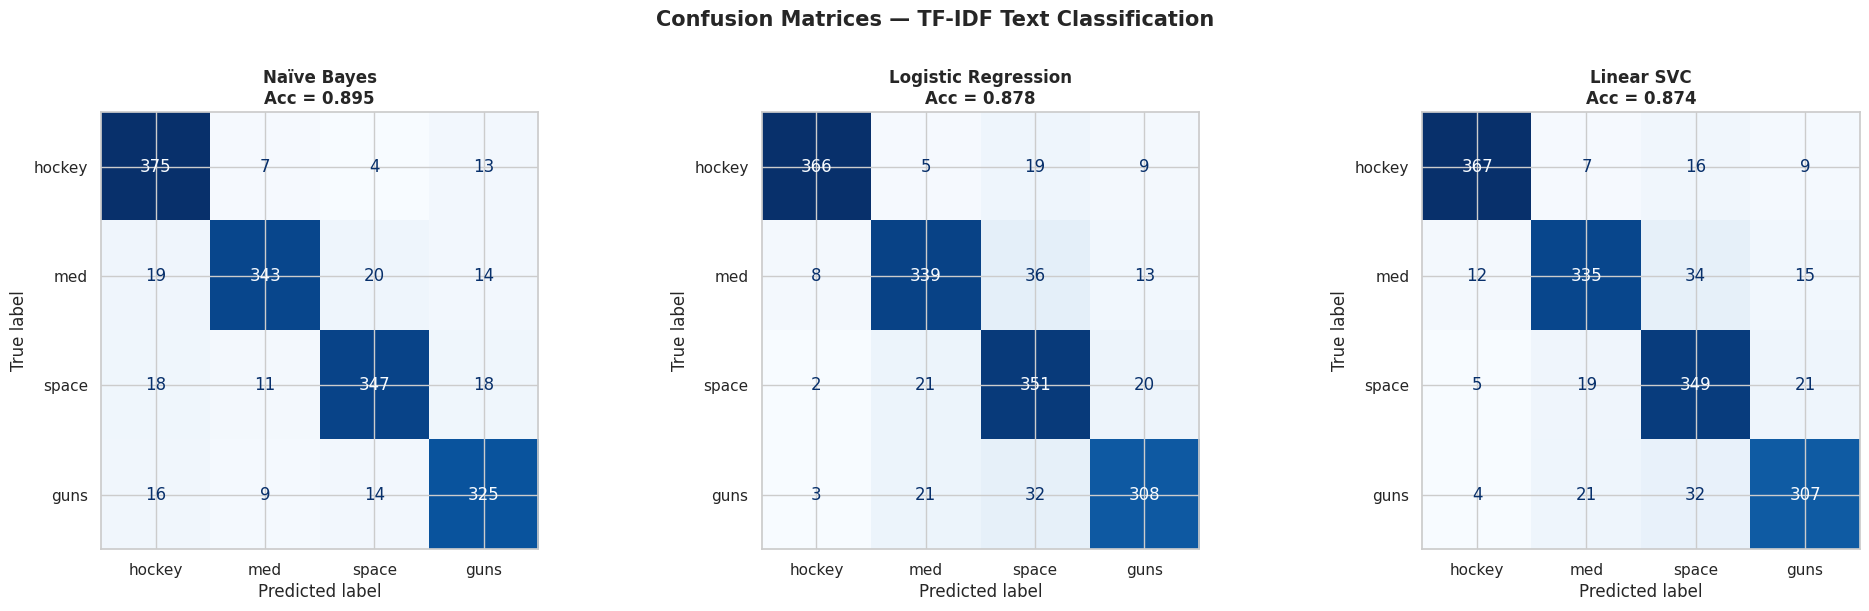

In [25]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices — TF-IDF Text Classification',
             fontsize=15, fontweight='bold', y=1.01)

for ax, (name, res) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc = {res["accuracy"]:.3f}', fontweight='bold')

plt.tight_layout(); plt.show()

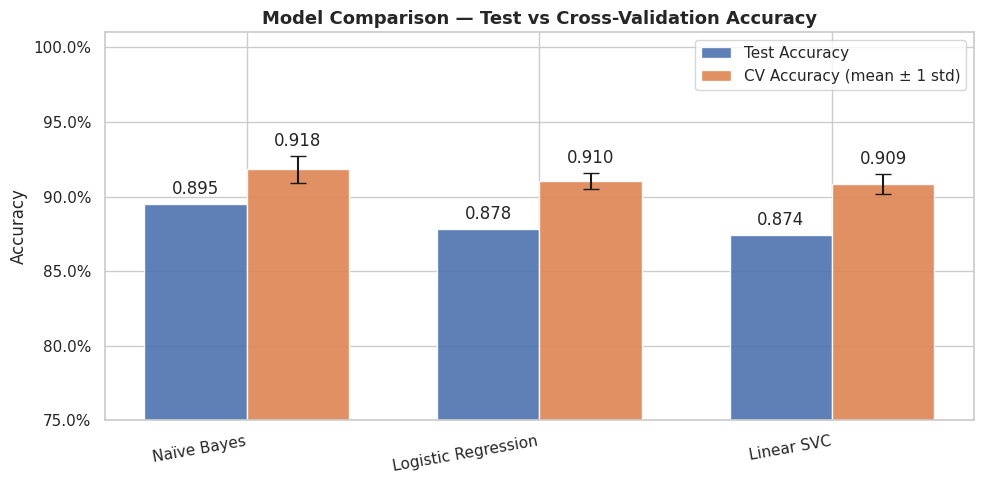

In [26]:
# ── Accuracy comparison — Test vs CV ─────────────────────────────────────────
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
cv_m  = [results[n]['cv_mean']  for n in names]
cv_s  = [results[n]['cv_std']   for n in names]

x, w = np.arange(len(names)), 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, accs, w, label='Test Accuracy',              color='#4C72B0', alpha=0.9)
b2 = ax.bar(x + w/2, cv_m, w, label='CV Accuracy (mean ± 1 std)', color='#DD8452',
            alpha=0.9, yerr=cv_s, capsize=6)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=10, ha='right', fontsize=11)
ax.set_ylim(0.75, 1.01); ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison — Test vs Cross-Validation Accuracy',
             fontsize=13, fontweight='bold')
ax.legend(); ax.bar_label(b1, fmt='%.3f', padding=4); ax.bar_label(b2, fmt='%.3f', padding=4)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout(); plt.show()

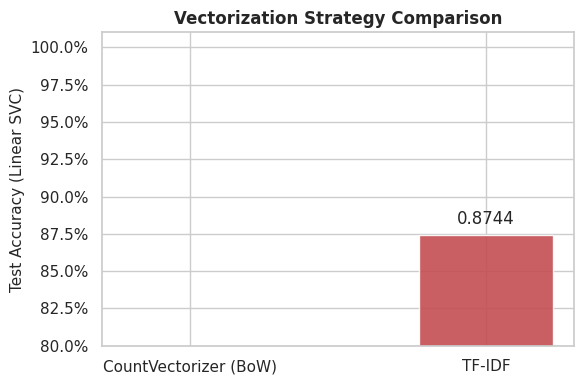

BoW accuracy   : 0.7849
TF-IDF accuracy: 0.8744
Improvement    : +8.95%


In [27]:
# ── CountVectorizer vs TF-IDF comparison (Linear SVC) ───────────────────────
svc_bow = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svc_bow.fit(X_train_cv, y_train)
acc_bow = accuracy_score(y_test, svc_bow.predict(X_test_cv))

svc_tfidf_ = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svc_tfidf_.fit(X_train_tfidf, y_train)
acc_tfidf_ = accuracy_score(y_test, svc_tfidf_.predict(X_test_tfidf))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['CountVectorizer (BoW)', 'TF-IDF'],
              [acc_bow, acc_tfidf_], color=['#55A868','#C44E52'], width=0.45, alpha=0.9)
ax.set_ylim(0.80, 1.01); ax.set_ylabel('Test Accuracy (Linear SVC)', fontsize=11)
ax.set_title('Vectorization Strategy Comparison', fontsize=12, fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=5, fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout(); plt.show()

print(f'BoW accuracy   : {acc_bow:.4f}')
print(f'TF-IDF accuracy: {acc_tfidf_:.4f}')
print(f'Improvement    : +{(acc_tfidf_ - acc_bow)*100:.2f}%')

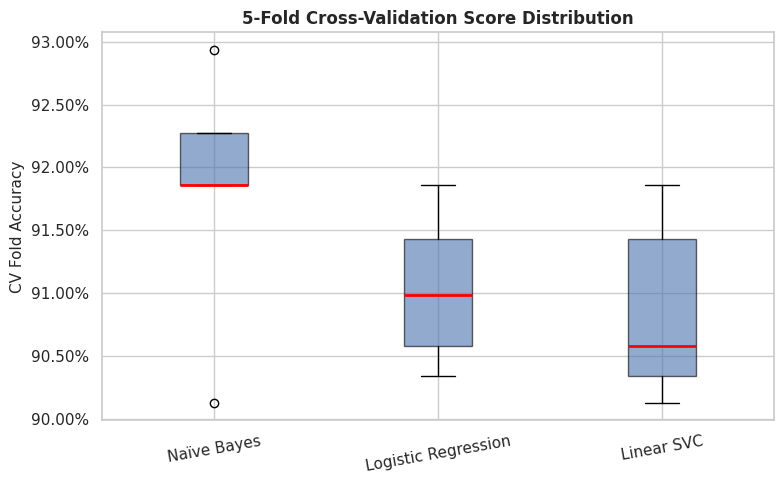

In [28]:
# ── Cross-validation score distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([results[n]['cv_scores'] for n in names], labels=names,
           patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('CV Fold Accuracy', fontsize=11)
ax.set_title('5-Fold Cross-Validation Score Distribution', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout(); plt.show()

# Step 6 — Analysis & Discussion

In [29]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': n, 'Test Accuracy': f"{r['accuracy']:.4f}",
     'CV Mean': f"{r['cv_mean']:.4f}", 'CV Std': f"±{r['cv_std']:.4f}"}
    for n, r in results.items()
])
display(summary.style.set_caption('Model Performance Summary'))

best_name = max(results, key=lambda n: results[n]['accuracy'])
print(f'\n🏆 Best model: {best_name}  (Acc={results[best_name]["accuracy"]:.4f})')

,Model,Test Accuracy,CV Mean,CV Std
0,Naïve Bayes,0.8950,0.9181,±0.0093
1,Logistic Regression,0.8783,0.9104,±0.0055
2,Linear SVC,0.8744,0.9087,±0.0067



🏆 Best model: Naïve Bayes  (Acc=0.8950)


In [30]:
# ── Predict on the custom CSV ─────────────────────────────────────────────────
best_model = results[best_name]['model']

X_custom_tfidf = tfidf_vec.transform(df_custom['clean_text'])
df_custom['predicted'] = [CLASS_NAMES[i] for i in best_model.predict(X_custom_tfidf)]
df_custom['correct']   = df_custom['label'] == df_custom['predicted']

acc_custom = df_custom['correct'].mean()
print(f'Model           : {best_name}')
print(f'Custom CSV Acc  : {acc_custom:.4f}  ({int(acc_custom*len(df_custom))}/{len(df_custom)} correct)\n')
display(df_custom[['text','label','predicted','correct']].head(12))

Model           : Naïve Bayes
Custom CSV Acc  : 0.9667  (116/120 correct)



,text,label,predicted,correct
0,NASA is planning to return humans to the Moon ...,sci.space,sci.space,True
1,The power forward played his 1000th career NHL...,rec.sport.hockey,rec.sport.hockey,True
2,A new poll shows majority of Americans support...,talk.politics.guns,talk.politics.guns,True
3,Advocates call for smarter gun technology to p...,talk.politics.guns,talk.politics.guns,True
4,The Supreme Court will hear arguments on the c...,talk.politics.guns,talk.politics.guns,True
5,Researchers have developed a new vaccine that ...,sci.med,sci.med,True
6,Law enforcement officials report a rise in ill...,talk.politics.guns,talk.politics.guns,True
7,The team recorded their best record in franchi...,rec.sport.hockey,rec.sport.hockey,True
8,The Second Amendment protects the right to bea...,talk.politics.guns,talk.politics.guns,True
9,Some argue that armed citizens deter crime whi...,talk.politics.guns,talk.politics.guns,True


In [31]:
# ── Predict on brand-new sentences ───────────────────────────────────────────
new_sentences = [
    'The astronauts completed repairs on the International Space Station.',
    'The patient was prescribed antibiotics for the bacterial infection.',
    'The hockey team won the championship in an exciting overtime match.',
    'The senator proposed stricter background checks for firearm purchases.',
    'Scientists discovered a new planet orbiting a nearby star system.',
    'Doctors recommend getting vaccinated before the flu season begins.',
]

cleaned_new = [preprocess(s) for s in new_sentences]
preds_new   = best_model.predict(tfidf_vec.transform(cleaned_new))

print(f'Model: {best_name}\n')
print(f'{"Input Sentence":<65} {"Predicted Label"}')
print('─' * 90)
for sent, pred_idx in zip(new_sentences, preds_new):
    print(f'{sent[:63]:<65} {CLASS_NAMES[pred_idx]}')

Model: Naïve Bayes

Input Sentence                                                    Predicted Label
──────────────────────────────────────────────────────────────────────────────────────────
The astronauts completed repairs on the International Space Sta   sci.space
The patient was prescribed antibiotics for the bacterial infect   sci.med
The hockey team won the championship in an exciting overtime ma   rec.sport.hockey
The senator proposed stricter background checks for firearm pur   talk.politics.guns
Scientists discovered a new planet orbiting a nearby star syste   sci.space
Doctors recommend getting vaccinated before the flu season begi   sci.med
